# Week 4 – Model Evaluation
### Cardiovascular Disease Risk Prediction


## 1. Import Libraries & Load Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv("cardio_cleaned.csv")
print("Shape of cleaned dataset:", df.shape)
df.head()

Shape of cleaned dataset: (68573, 14)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure
0,2,168,62.0,110,80,1,1,0,0,1,0,50.391781,21.967120,30
1,1,156,85.0,140,90,3,1,0,0,1,1,55.419178,34.927679,50
2,1,165,64.0,130,70,3,1,0,0,0,1,51.663014,23.507805,60
3,2,169,82.0,150,100,1,1,0,0,1,1,48.282192,28.710479,50
4,1,156,56.0,100,60,1,1,0,0,0,0,47.873973,23.011177,40


## 2. Rebuild Scaled Features & Train-Test Split



In [3]:
continuous_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[continuous_cols] = scaler.fit_transform(df[continuous_cols])

X = df_scaled.drop(columns=['cardio'])
y = df_scaled['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True).round(3))
print("y_test distribution:\n", y_test.value_counts(normalize=True).round(3))

X_train: (54858, 13)  X_test: (13715, 13)
y_train distribution:
 cardio
0    0.505
1    0.495
Name: proportion, dtype: float64
y_test distribution:
 cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


## 3. Retrain the Two Models From Week 3

In [4]:
library_model = LogisticRegression(max_iter=1000, random_state=42)
library_model.fit(X_train, y_train)

y_pred_library = library_model.predict(X_test)
y_proba_library = library_model.predict_proba(X_test)[:, 1]

library_train_acc = accuracy_score(y_train, library_model.predict(X_train))
library_test_acc = accuracy_score(y_test, y_pred_library)

print(f"scikit-learn Logistic Regression — Train Accuracy: {library_train_acc:.4f}")
print(f"scikit-learn Logistic Regression — Test Accuracy:  {library_test_acc:.4f}")

scikit-learn Logistic Regression — Train Accuracy: 0.7277
scikit-learn Logistic Regression — Test Accuracy:  0.7258


In [5]:
class CustomLogisticRegression:

    def __init__(self, learning_rate=0.1, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)  # numerical stability guard
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0.0

        for i in range(self.n_iterations):
            linear_output = X @ self.weights + self.bias
            y_pred = self._sigmoid(linear_output)

            error = y_pred - y
            dw = (1 / m) * (X.T @ error)
            db = (1 / m) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            eps = 1e-15  # avoid log(0)
            cost = -(1 / m) * np.sum(
                y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
            )
            self.cost_history.append(cost)

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


scratch_model = CustomLogisticRegression(learning_rate=0.1, n_iterations=2000)
scratch_model.fit(X_train.values, y_train.values)

y_pred_scratch = scratch_model.predict(X_test.values)
y_proba_scratch = scratch_model.predict_proba(X_test.values)

scratch_train_acc = accuracy_score(y_train, scratch_model.predict(X_train.values))
scratch_test_acc = accuracy_score(y_test, y_pred_scratch)

print(f"Scratch Logistic Regression — Train Accuracy: {scratch_train_acc:.4f}")
print(f"Scratch Logistic Regression — Test Accuracy:  {scratch_test_acc:.4f}")

Scratch Logistic Regression — Train Accuracy: 0.7279
Scratch Logistic Regression — Test Accuracy:  0.7250


## 4. Classification Metrics on the Test Set



In [6]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate_model('scikit-learn Logistic Regression', y_test, y_pred_library, y_proba_library),
    evaluate_model('Custom (NumPy) Logistic Regression', y_test, y_pred_scratch, y_proba_scratch),
]).set_index('Model').round(4)

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
scikit-learn Logistic Regression,0.7258,0.7533,0.6630,0.7053,0.7894
Custom (NumPy) Logistic Regression,0.7250,0.7522,0.6624,0.7044,0.7896


In [7]:
print("scikit-learn Logistic Regression — Classification Report")
print(classification_report(y_test, y_pred_library))

print("\nCustom (NumPy) Logistic Regression — Classification Report")
print(classification_report(y_test, y_pred_scratch))

scikit-learn Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6929
           1       0.75      0.66      0.71      6786

    accuracy                           0.73     13715
   macro avg       0.73      0.73      0.72     13715
weighted avg       0.73      0.73      0.72     13715


Custom (NumPy) Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6929
           1       0.75      0.66      0.70      6786

    accuracy                           0.72     13715
   macro avg       0.73      0.72      0.72     13715
weighted avg       0.73      0.72      0.72     13715



## 5. Confusion Matrices

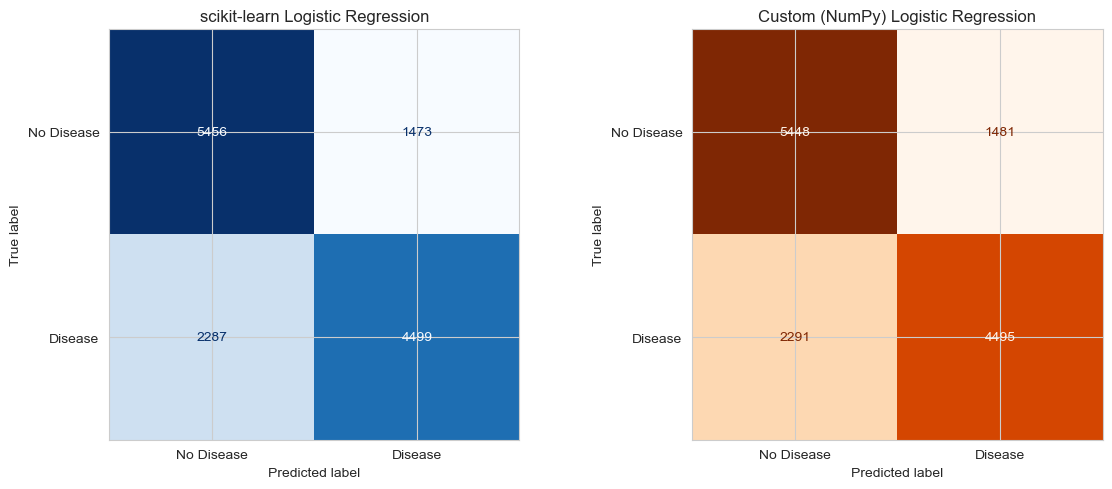

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_library),
                       display_labels=['No Disease', 'Disease']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('scikit-learn Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_scratch),
                       display_labels=['No Disease', 'Disease']).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Custom (NumPy) Logistic Regression')

plt.tight_layout()
plt.show()

## 6. ROC Curves

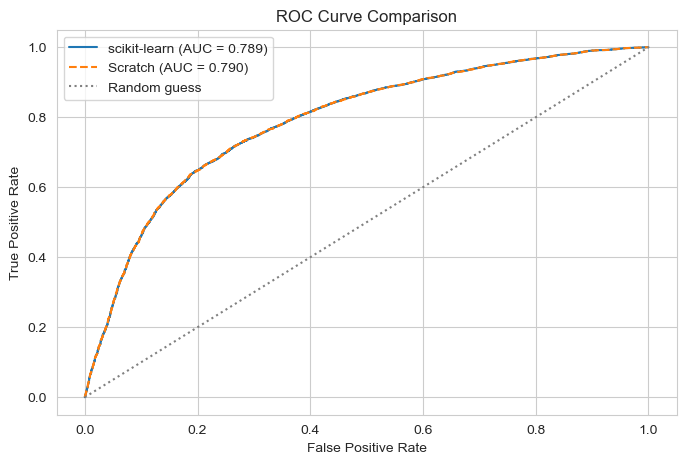

In [9]:
fpr_lib, tpr_lib, _ = roc_curve(y_test, y_proba_library)
fpr_scr, tpr_scr, _ = roc_curve(y_test, y_proba_scratch)

plt.plot(fpr_lib, tpr_lib, label=f"scikit-learn (AUC = {roc_auc_score(y_test, y_proba_library):.3f})")
plt.plot(fpr_scr, tpr_scr, label=f"Scratch (AUC = {roc_auc_score(y_test, y_proba_scratch):.3f})", linestyle='--')
plt.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 7. Overfitting / Underfitting Check



In [10]:
gap_lib = library_train_acc - library_test_acc
gap_scr = scratch_train_acc - scratch_test_acc

overfit_check = pd.DataFrame({
    'Model': ['scikit-learn Logistic Regression', 'Custom (NumPy) Logistic Regression'],
    'Train Accuracy': [library_train_acc, scratch_train_acc],
    'Test Accuracy': [library_test_acc, scratch_test_acc],
    'Train − Test Gap': [gap_lib, gap_scr],
}).round(4)

overfit_check

,Model,Train Accuracy,Test Accuracy,Train − Test Gap
0,scikit-learn Logistic Regression,0.7277,0.7258,0.0018
1,Custom (NumPy) Logistic Regression,0.7279,0.7250,0.0030


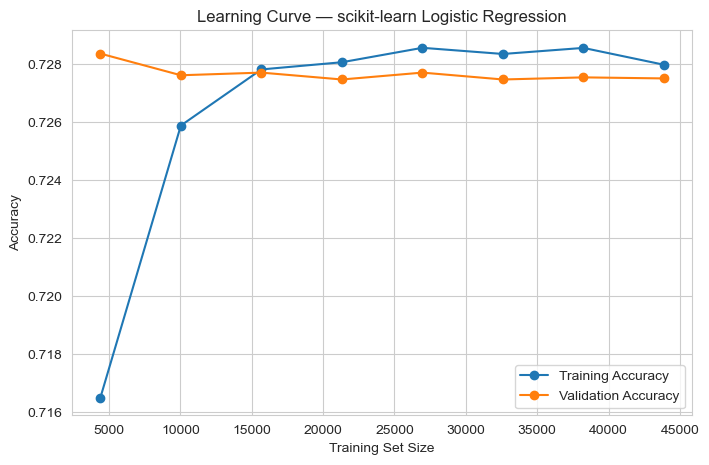

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, 'o-', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 'o-', label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — scikit-learn Logistic Regression')
plt.legend()
plt.show()

## 8. Cost Convergence Check (Scratch Model)


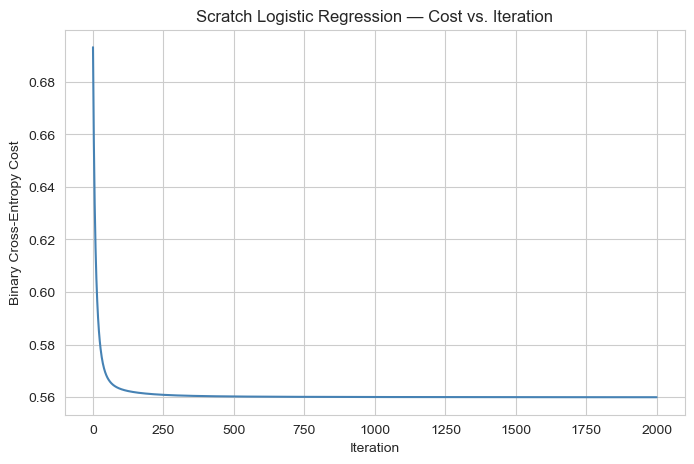

Final cost: 0.55996
Cost change over last 100 iterations: 0.000004


In [12]:
plt.plot(scratch_model.cost_history, color='steelblue')
plt.title('Scratch Logistic Regression — Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Cost')
plt.show()

print(f"Final cost: {scratch_model.cost_history[-1]:.5f}")
print(f"Cost change over last 100 iterations: "
      f"{scratch_model.cost_history[-100] - scratch_model.cost_history[-1]:.6f}")